<a href="https://colab.research.google.com/github/Maneesh290318/Machine-Learning-Algorithms/blob/main/Reeinforced_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Reinforcement Learning

Reinforcement Learning (RL) is a type of machine learning where an 'agent' learns to make decisions by trying different actions in an environment and receiving 'rewards' or 'penalties' for those actions. The goal is for the agent to learn a strategy (or 'policy') that maximizes its total reward over time.

Think of it like training a pet: if it does something good, you give it a treat (reward); if it does something bad, you might gently correct it (penalty). Over time, the pet learns which behaviors lead to treats and which don't.

### Simple Business Example: Optimizing Marketing Campaigns

Imagine an online retailer wants to optimize which marketing offer to show to a customer when they visit their website. The goal is to maximize the chance of the customer making a purchase.

*   **Agent**: The AI system deciding which marketing offer to display.
*   **Environment**: The customer's interaction with the website and the offers presented.
*   **Actions**: The different marketing offers the agent can choose to show (e.g., "10% off your first purchase", "Free shipping on orders over $50", "Buy one get one free").
*   **Reward**: A positive reward if the customer makes a purchase after seeing an offer, and a small negative reward or zero reward if they don't.

**How it works:**

1.  **Exploration**: Initially, the RL agent might randomly show different offers to different customers to see what happens.
2.  **Learning**: When a customer makes a purchase after seeing a specific offer, the agent gets a positive reward, reinforcing that choice. If a customer leaves without buying, the agent learns that the offer might not have been effective for that type of customer or in that context.
3.  **Optimization**: Over time, by continuously trying different offers and observing the outcomes (rewards), the agent learns which offers are most effective for various customer segments, product types, or times of day. It starts to prioritize offers that historically lead to more purchases.

**Business Benefit**: By continuously adapting and learning from customer responses, the retailer can dynamically tailor marketing offers, leading to higher conversion rates, increased sales, and more efficient use of marketing budget, without needing explicit rules programmed beforehand.

### Code Demonstration: Simple Marketing Offer Optimization

We'll simulate a very basic scenario where we have a few marketing offers, and our RL agent needs to learn which one is most effective over time. For simplicity, each offer will have a fixed (but unknown to the agent initially) conversion rate.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Define the conversion rates for different offers (unknown to the agent)
# These are the 'true' probabilities of a customer converting for each offer
offer_conversion_rates = {
    'Offer A': 0.05, # 5% conversion
    'Offer B': 0.15, # 15% conversion
    'Offer C': 0.10  # 10% conversion
}

offers = list(offer_conversion_rates.keys())
num_offers = len(offers)

print(f"Available Offers: {offers}")

Available Offers: ['Offer A', 'Offer B', 'Offer C']


In [ ]:
# Simulate a customer interaction
# The environment gives a reward (1 for purchase, 0 for no purchase)
def get_reward(chosen_offer):
    conversion_rate = offer_conversion_rates[chosen_offer]
    # Simulate if the customer makes a purchase based on the conversion rate
    return 1 if np.random.rand() < conversion_rate else 0

# Simple Reinforcement Learning Agent (Epsilon-Greedy Strategy)
class RLAgent:
    def __init__(self, num_actions, epsilon=0.1, learning_rate=0.1):
        self.num_actions = num_actions
        self.epsilon = epsilon  # Exploration vs. Exploitation trade-off
        self.learning_rate = learning_rate # How quickly to update value estimates
        self.q_values = np.zeros(num_actions) # Estimated value of each action
        self.action_counts = np.zeros(num_actions) # How many times each action was taken

    def choose_action(self):
        if np.random.rand() < self.epsilon: # Explore: choose a random action
            return np.random.randint(self.num_actions)
        else: # Exploit: choose the action with the highest estimated value
            return np.argmax(self.q_values)

    def update_q_value(self, action, reward):
        # Simple update rule (e.g., incremental average or Q-learning like update)
        # For simplicity, we'll use an incremental average for this demo
        self.action_counts[action] += 1
        # Weighted average update: new_Q = old_Q + learning_rate * (reward - old_Q)
        self.q_values[action] = self.q_values[action] + self.learning_rate * (reward - self.q_values[action])

# Initialize the agent
agent = RLAgent(num_actions=num_offers, epsilon=0.2, learning_rate=0.1)

### Running the Simulation

We'll run the simulation for a number of 'customer interactions' (timesteps). In each step, the agent chooses an offer, receives a reward, and updates its understanding of the offers' effectiveness.


--- Simulation Results ---
Final Estimated Q-Values (Conversion Rates):
  Offer A: 0.0135
  Offer B: 0.1681
  Offer C: 0.1006

True Conversion Rates:
  Offer A: 0.0500
  Offer B: 0.1500
  Offer C: 0.1000


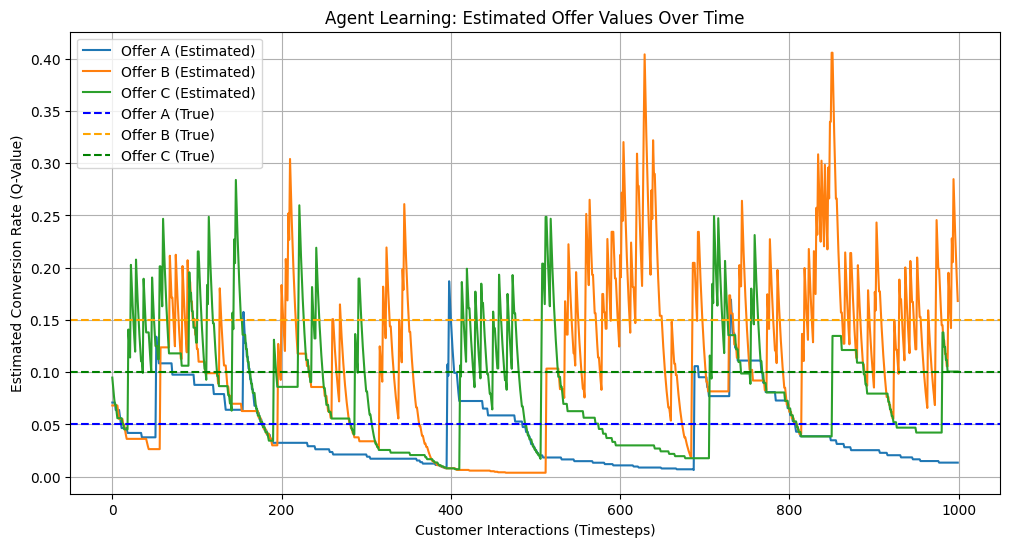

,Times Chosen
chosen_offer,
Offer A,107
Offer B,536
Offer C,357


In [ ]:
num_timesteps = 1000
history = []

for t in range(num_timesteps):
    # Agent chooses an offer
    action_index = agent.choose_action()
    chosen_offer = offers[action_index]

    # Environment provides a reward
    reward = get_reward(chosen_offer)

    # Agent learns from the reward
    agent.update_q_value(action_index, reward)

    # Record history for analysis
    history.append({
        'timestep': t,
        'chosen_offer': chosen_offer,
        'reward': reward,
        'q_values_A': agent.q_values[offers.index('Offer A')],
        'q_values_B': agent.q_values[offers.index('Offer B')],
        'q_values_C': agent.q_values[offers.index('Offer C')]
    })

history_df = pd.DataFrame(history)

print("\n--- Simulation Results ---")
print("Final Estimated Q-Values (Conversion Rates):")
for i, offer in enumerate(offers):
    print(f"  {offer}: {agent.q_values[i]:.4f}")

print("\nTrue Conversion Rates:")
for offer, rate in offer_conversion_rates.items():
    print(f"  {offer}: {rate:.4f}")

# Visualize how Q-values evolve over time
plt.figure(figsize=(12, 6))
plt.plot(history_df['timestep'], history_df['q_values_A'], label='Offer A (Estimated)')
plt.plot(history_df['timestep'], history_df['q_values_B'], label='Offer B (Estimated)')
plt.plot(history_df['timestep'], history_df['q_values_C'], label='Offer C (Estimated)')

# Plot true values for comparison
plt.axhline(y=offer_conversion_rates['Offer A'], color='blue', linestyle='--', label='Offer A (True)')
plt.axhline(y=offer_conversion_rates['Offer B'], color='orange', linestyle='--', label='Offer B (True)')
plt.axhline(y=offer_conversion_rates['Offer C'], color='green', linestyle='--', label='Offer C (True)')

plt.title('Agent Learning: Estimated Offer Values Over Time')
plt.xlabel('Customer Interactions (Timesteps)')
plt.ylabel('Estimated Conversion Rate (Q-Value)')
plt.legend()
plt.grid(True)
plt.savefig('agent_learning_plot.png') # Save the plot to a file
plt.show()

# Display the frequency of choosing each offer
display(history_df['chosen_offer'].value_counts().sort_index().to_frame('Times Chosen'))

# Explanation of the diagram:
# X-axis (Customer Interactions (Timesteps)): This represents the number of customer interactions or discrete time steps in our simulation.
# Y-axis (Estimated Conversion Rate (Q-Value)): This shows the agent's current estimate of the conversion rate (or "value") for each offer.
# Solid Lines (Estimated Q-Values): Each solid line shows how the agent's estimated conversion rate for that specific offer changes over time.
# Dashed Lines (True Conversion Rates): These horizontal dashed lines represent the actual, underlying conversion rates for each offer.
# What the plot tells us: The plot visualizes the learning process of the RL agent, showing how the estimated Q-values converge towards the true conversion rates over time.

# Explanation of num_timesteps:
# `num_timesteps == 1000` means the simulation runs for 1000 iterations. Each iteration is a 'customer interaction' where the agent makes a decision, gets a reward, and learns. This entire period of 1000 timesteps serves as the training or learning phase for the RL agent.

# Explanation of epsilon (from the RLAgent class):
# 'epsilon' is a parameter that controls the trade-off between exploration and exploitation in the agent's learning strategy.
# - With probability 'epsilon' (e.g., 0.2 or 20%), the agent will 'explore' by choosing a random action (offer), even if it doesn't currently believe it's the best one. This helps the agent discover potentially better actions it hasn't tried much yet.
# - With probability `1 - epsilon` (e.g., 0.8 or 80%), the agent will 'exploit' by choosing the action it currently believes has the highest estimated value (Q-value). This allows the agent to leverage what it has already learned to maximize rewards.
# This balance is crucial for effective reinforcement learning: too much exploration can be inefficient, while too much exploitation can lead to missing out on better, undiscovered options.

### Interpretation of Results

As you can see from the plot and the final estimated Q-values, the agent, over many interactions, starts to estimate the true conversion rates of each offer. It also begins to choose the best-performing offer (Offer B in this case) more frequently, even though it still explores other options due to the `epsilon` parameter.

This simple example illustrates how an RL agent can learn to optimize decisions (which marketing offer to show) in an environment by trial and error, without being explicitly programmed with the best offer beforehand. In a real-world scenario, the 'conversion rates' might change, and the RL agent would adapt to these changes over time.

---

#### Epsilon (Exploration vs. Exploitation)

The `epsilon` parameter is a critical concept in Reinforcement Learning, particularly for algorithms like the one used here (epsilon-greedy). It dictates the balance between two fundamental strategies:

*   **Exploration**: Trying new actions that the agent hasn't fully evaluated yet. This is important because the agent doesn't know the true value of each action initially and needs to gather information.
*   **Exploitation**: Choosing the action that the agent currently believes is the best, based on its accumulated knowledge, to maximize immediate rewards.

In our `RLAgent`, `epsilon` works as follows:

*   **With a probability of `epsilon`** (e.g., 0.2 or 20%), the agent will choose to **explore**. This means it will randomly pick one of the available offers, regardless of its current estimated value. This ensures that even offers that might initially seem bad, or those it hasn't tried much, get a chance to be evaluated.
*   **With a probability of `1 - epsilon`** (e.g., 0.8 or 80%), the agent will choose to **exploit**. This means it will select the offer that currently has the highest estimated conversion rate (Q-value). This allows the agent to capitalize on what it has learned so far.

**Why is this balance important?**

*   If `epsilon` is too low (agent primarily exploits), the agent might quickly settle on a suboptimal offer and never discover a truly better one.
*   If `epsilon` is too high (agent primarily explores), it might spend too much time trying out random offers, leading to inefficient learning and missed opportunities for higher rewards.

The chosen `epsilon` value (0.2 in our simulation) is a hyperparameter that often needs tuning to find the sweet spot for a given problem, allowing the agent to learn effectively without getting stuck in local optima.